### [데이터 전처리 - 통합 전처리] <hr>

- 다양한 피쳐의 전처리를 한번에 진행 : ColumnTransformer
    * sklearn.compose 모듈에 존재 
    * 변환 후 컬럼명 체크 필수!!

- **[0] 모듈로딩**

In [14]:
## 데이터 분석 관련
import pandas as pd
import numpy as np

## 시각화 관련
import matplotlib.pyplot as plt

## ML 데이터셋 관련
from sklearn.model_selection import train_test_split 

## ML 데이터 전처리 관련
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder 
from sklearn.compose import ColumnTransformer

- **[1] 데이터 준비**

In [15]:
## 데이터 준비
DATA_FILE = '../Data/Numbers/imbalanced_data.csv'

## 데이터 로딩 => 첫번째 컬럼명, 쉼표로 데이터 구분
df = pd.read_csv(DATA_FILE)

In [16]:
## 기본 정보 확인
df.info()
display( df.head() )

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   city         500 non-null    str  
 1   grade        500 non-null    str  
 2   gender       500 non-null    str  
 3   age          500 non-null    int64
 4   visit_count  500 non-null    int64
 5   avg_price    500 non-null    int64
 6   target       500 non-null    int64
dtypes: int64(4), str(3)
memory usage: 27.5 KB


,city,grade,gender,age,visit_count,avg_price,target
0,부산,Silver,Male,21,5,322579,1
1,제주,Silver,Female,25,6,73965,0
2,대구,Bronze,Female,47,4,342066,0
3,대구,Gold,Female,48,8,107799,0
4,서울,Silver,Female,45,9,103948,0


- **[2] 클래스 비율 확인** 


In [17]:
##=> 클래스별 개수
df['target'].value_counts()

target
0    450
1     50
Name: count, dtype: int64

In [18]:
##=> 클래스별 비율
df['target'].value_counts(normalize=True)

target
0    0.9
1    0.1
Name: proportion, dtype: float64

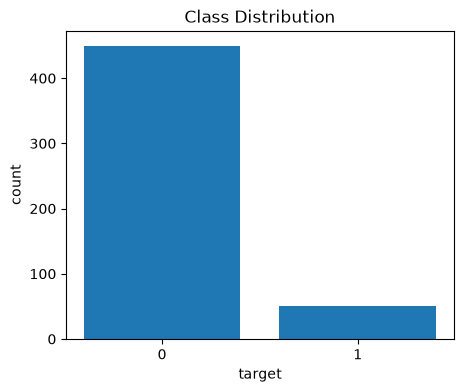

In [19]:
## => 시각화
class_counts = df['target'].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)

plt.xlabel('target')
plt.ylabel('count')
plt.title('Class Distribution')
plt.show()

- **[3]데이터셋 준비**

In [20]:
## 피쳐와 타겟 분리
featureDF = df[df.columns[:-1]]
targetSR  = df[df.columns[-1]]

In [21]:
## ----------------------------------------------------------
## 학습용 | 테스트용 데이터셋 준비
## ----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(featureDF, 
                                                    targetSR,
                                                    test_size=0.2,
                                                    random_state=10,
                                                    stratify=targetSR)

- **[4]전처리**

In [ ]:
## ----------------------------------------------------------
## - 수치형 컬럼/피쳐 : age,visit_count,avg_price               
## - 범주형 컬럼/피쳐 : 순서 유지 인코딩 : grade 
##                    순서 없는 인코딩 : city, gender                
## ----------------------------------------------------------
## => 전처리별 컬럼명
str_cols, sord_cols, num_cols = df.columns[:3:2], df.columns[[1]], df.columns[3:-1]

print(f'str_cols    : {str_cols}\nsord_cols   : {sord_cols}\nnum_cols    : {num_cols}')

str_cols    : Index(['city', 'gender'], dtype='str')
sord_cols   : Index(['grade'], dtype='str')
num_cols    : Index(['age', 'visit_count', 'avg_price'], dtype='str')


In [43]:
## ---------------------------------------------------------------
## 통합 전처리 인스턴스 생성
## - 컬럼별 전처리기 지정
## ---------------------------------------------------------------
preprocessing = ColumnTransformer(transformers=[
                                    ('ordEncoder', OrdinalEncoder(), sord_cols),
                                    ('ohEncoder', OneHotEncoder(), str_cols),
                                    ('stdScaler', StandardScaler(), num_cols),
                                ])

preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ordEncoder', ...), ('ohEncoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` an

In [44]:
## => .fit(학습용피쳐, 학습용타겟) : 전처리 연산 준비 진행 
preprocessing.fit(X_train, y_train)

## => 데이터 기반 준비된 모델 파라미터들
print( f'feature_names_in_      : {preprocessing.feature_names_in_}')
print( f'named_transformers_    : {preprocessing.named_transformers_}')
print( f'transformers_          : {preprocessing.transformers_}')
print( f'output_indices_        : {preprocessing.output_indices_}')


feature_names_in_      : ['city' 'grade' 'gender' 'age' 'visit_count' 'avg_price']
named_transformers_    : {'ordEncoder': OrdinalEncoder(), 'ohEncoder': OneHotEncoder(), 'stdScaler': StandardScaler()}
transformers_          : [('ordEncoder', OrdinalEncoder(), Index(['grade'], dtype='str')), ('ohEncoder', OneHotEncoder(), Index(['city', 'gender'], dtype='str')), ('stdScaler', StandardScaler(), Index(['age', 'visit_count', 'avg_price'], dtype='str'))]
output_indices_        : {'ordEncoder': slice(0, 1, None), 'ohEncoder': slice(1, 9, None), 'stdScaler': slice(9, 12, None), 'remainder': slice(0, 0, None)}


In [48]:
## => 전처리 진행 및 변환 
X_train_trans = preprocessing.transform(X_train)
X_test_trans  = preprocessing.transform(X_test)

## => 확인
print(f'X_train.iloc[0]  => {X_train.iloc[0].to_list()}')
print(f'X_train_trans[0] => {X_train_trans[0].tolist()}')

X_train.iloc[0]  => ['대구', 'Gold', 'Female', np.int64(27), np.int64(8), np.int64(328903)]
X_train_trans[0] => [1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, -1.106072545547417, 1.4407346437774422, 1.4276906457068157]


- **[5]학습진행** 

In [51]:
## ML 모델 로딩
from sklearn.neighbors import KNeighborsClassifier 

## 모델 인스턴스 생성
kModel = KNeighborsClassifier()

## 학습진행
kModel.fit(X_train_trans, y_train)

## 성능
train_score = kModel.score(X_train_trans, y_train)
test_score  = kModel.score(X_test_trans, y_test)

print(f'[Train Score] {train_score}  [Test Score] {test_score}')

[Train Score] 0.905  [Test Score] 0.9
